In [1680]:
%%bash

g++ -std=c++17 -Wall main.cpp Mesh.cpp Flux.cpp Solver.cpp Cell.cpp -o myprogram



In [1681]:
%%bash
./myprogram

Shape = (832, 4)
setting pointersShape = (832, 4)
setting pointersSetting ambient Conditions...Iteration 0
Iteration 1
Iteration 2
Iteration 3
Iteration 4
Iteration 5
Iteration 6
Iteration 7
Iteration 8
Iteration 9
Iteration 10
Iteration 11
Iteration 12
Iteration 13
Iteration 14
Iteration 15
Iteration 16
Iteration 17
Iteration 18
Iteration 19
Iteration 20
Iteration 21
Iteration 22
Iteration 23
Iteration 24
Iteration 25
Iteration 26
Iteration 27
Iteration 28
Iteration 29
Iteration 30
Iteration 31
Iteration 32


Iteration 33
Iteration 34
Iteration 35
Iteration 36
Iteration 37
Iteration 38
Iteration 39
Iteration 40
Iteration 41
Iteration 42
Iteration 43
Iteration 44
Iteration 45
Iteration 46
Iteration 47
Iteration 48
Iteration 49
Iteration 50
Iteration 51
Iteration 52
Iteration 53
Iteration 54
Iteration 55
Iteration 56
Iteration 57
Iteration 58
Iteration 59
Iteration 60
Iteration 61
Iteration 62
Iteration 63
Iteration 64
Iteration 65
Iteration 66
Iteration 67
Iteration 68
Iteration 69
Iteration 70
Iteration 71
Iteration 72
Iteration 73
Iteration 74
Iteration 75
Iteration 76
Iteration 77
Iteration 78
Iteration 79
Iteration 80
Iteration 81
Iteration 82
Iteration 83
Iteration 84
Iteration 85
Iteration 86
Iteration 87
Iteration 88
Iteration 89
Iteration 90
Iteration 91
Iteration 92
Iteration 93
Iteration 94
Iteration 95
Iteration 96
Iteration 97
Iteration 98
Iteration 99
0.13395
0.25274
0.465342
0.831316
1.41006
2.19553
3.00169
3.44936
3.25474
2.54841
1.72072
1.04966
-0.00483994
-0.00356908
-0.0033

In [1682]:
import numpy as np

In [1683]:
xx = x
yy = y

xx_top_bottom = (xx[:,1:]+xx[:,0:-1])/2
yy_top_bottom = (yy[:,1:]+yy[:,0:-1])/2
nxi_top = -(yy[:,1:]-yy[:,0:-1])
nyi_top = xx[:,1:]-xx[:,0:-1]



A_top_bottom = np.sqrt((xx[:,1:]-xx[:,0:-1])**2+(yy[:,1:]-yy[:,0:-1])**2)
A_left_right = np.sqrt((xx[1:,:]-xx[0:-1,:])**2+(yy[1:,:]-yy[0:-1,:])**2)

A_left = np.einsum("ij,jkl->ikl",np.ones((4,1)),(A_left_right[np.newaxis,:,0:-1]))
A_right = np.einsum("ij,jkl->ikl",np.ones((4,1)),(A_left_right[np.newaxis,:,1:]))
A_top = np.einsum("ij,jkl->ikl",np.ones((4,1)),(A_top_bottom[np.newaxis,1:,:]))
A_bottom = np.einsum("ij,jkl->ikl",np.ones((4,1)),(A_top_bottom[np.newaxis,0:-1,:]))

A_LR = np.einsum("ij,jkl->ikl",np.ones((4,1)),(A_left_right[np.newaxis,:,:]))
A_UD = np.einsum("ij,jkl->ikl",np.ones((4,1)),(A_top_bottom[np.newaxis,:,:]))

xx_left_right = ((xx[1:,:]+xx[0:-1,:])/2)
yy_left_right = ((yy[1:,:]+yy[0:-1,:])/2)
nxi_left_right = -(yy[1:,:]-yy[0:-1,:])
nyi_left_right = (xx[1:,:]-xx[0:-1,:])


downward_normal = np.array([xx_top_bottom,yy_top_bottom,-(nxi_top/A_top_bottom),-(nyi_top/A_top_bottom)])
upward_normal = np.array([xx_top_bottom,yy_top_bottom,(nxi_top/A_top_bottom),(nyi_top/A_top_bottom)])
leftward_normal = np.array([xx_left_right,yy_left_right,(nxi_left_right/A_left_right),(nyi_left_right/A_left_right)])
rightward_normal = np.array([xx_left_right,yy_left_right,-(nxi_left_right/A_left_right),-(nyi_left_right/A_left_right)])


In [1684]:
nx_D = [-(nxi_top/A_top_bottom),-(nyi_top/A_top_bottom)]


In [1685]:
import numpy as np

In [1686]:
NI = 17  # same as in C++
NJ = 53
x = np.fromfile("Ramp_Coarse_xx.bin", dtype=np.float64).reshape((NI,NJ))
y = np.fromfile("Ramp_Coarse_yy.bin",dtype=np.float64).reshape((NI,NJ))

#x = np.loadtxt("Ramp_Coarse_xx.csv", delimiter=",",dtype=np.float64).reshape((NI,NJ))
#y = np.loadtxt("Ramp_Coarse_yy.csv",delimiter=",",dtype=np.float64).reshape((NI,NJ))
#np.savetxt("Ramp_Coarse_xx.csv",x,delimiter=",")
#np.savetxt("Ramp_Coarse_yy.csv",y,delimiter=",")


In [1687]:
import matplotlib.pyplot as plt

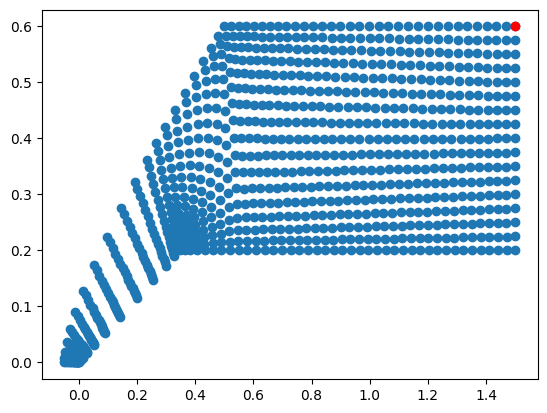

In [1688]:
plt.scatter(x[::-1],y[::-1])
plt.plot((x[::-1])[0,-1],(y[::-1])[0,-1],"o",color = "red")


x_temp = x[::-1]
y_temp = y[::-1]

x11 = x[0:-1,0:-1]
x12 = x[0:-1,1:]
x21 = x[1:,0:-1]
x22 = x[1:,1:]

y11 = y[0:-1,0:-1]
y12 = y[0:-1,1:]
y21 = y[1:,0:-1]
y22 = y[1:,1:]

In [1689]:
x_cells= np.array([x21,x22,x11,x12])
y_cells = np.array([y21,y22,y11,y12])


In [1690]:
x_cells = x_cells.reshape((4,x11.shape[0]*x11.shape[1]))
y_cells = y_cells.reshape((4,x11.shape[0]*x11.shape[1]))

np.savetxt("Ramp_Coarse_cells_xx.csv",(x_cells.T).copy(),delimiter=",")
np.savetxt("Ramp_Coarse_cells_yy.csv",(y_cells.T).copy(),delimiter=",")

In [1691]:
x_cells.shape

(4, 832)

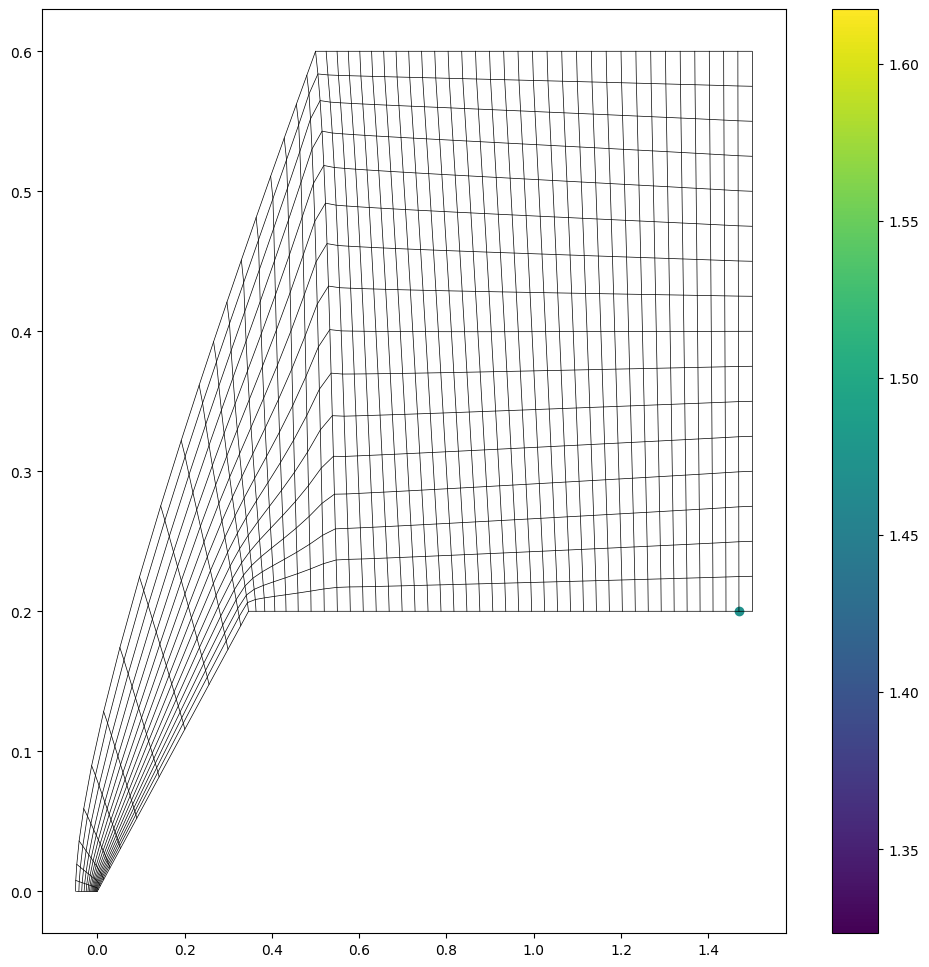

In [1692]:
fig, ax = plt.subplots(figsize=(12,12))
for j in range(xx.shape[1]):
    ax.plot(xx[:, j], yy[:, j], 'k-', linewidth=0.5)

# Plot horizontal lines (loop over rows)
for i in range(xx.shape[0]):
    ax.plot(xx[i, :], yy[i, :], 'k-', linewidth=0.5)
index = 51
plt.scatter(x_cells[2,index],y_cells[2,index],c=x_cells[2,index])
plt.colorbar()

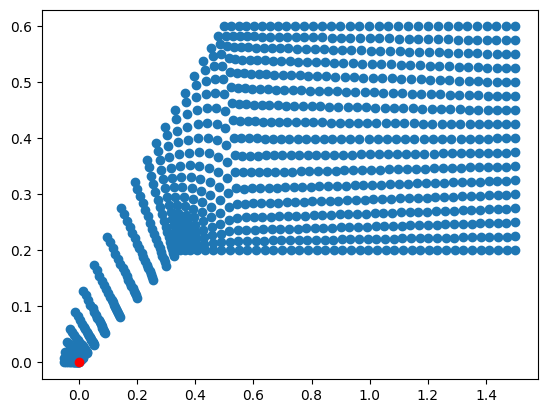

In [1693]:
plt.scatter(x,y)
plt.plot(x[0,0],y[0,0],"o",color="red")

In [1694]:
#plt.scatter(x,y)
#plt.plot((x[::-1,:])[0,0],(y[::-1,:])[0,0],"o",color="r")
np.savetxt("Ramp_Coarse_xx.csv",(x).copy(),delimiter=",")
np.savetxt("Ramp_Coarse_yy.csv",(y).copy(),delimiter=",")

In [1695]:
import numpy as np
import matplotlib.pyplot as plt
NI = 17  # same as in C++
NJ = 53

#residual = np.fromfile("midpoint_yy.bin", dtype=np.float64).reshape((NI-1, NJ-1))

#print(residual)
#plt.imshow(residual)

#plt.colorbar()

In [1696]:
NI = 16  # same as in C++
NJ = 52
NI = 128  # same as in C++
NJ = 416
#midpointxx = np.fromfile("midpoint_xx.bin", dtype=np.float64).reshape((NI-1, NJ-1))
#midpointyy = np.fromfile("midpoint_yy.bin", dtype=np.float64).reshape((NI-1, NJ-1))
volume = np.fromfile("volume2.bin", dtype=np.float64).reshape((NI, NJ))
#plt.scatter(midpointxx,midpointyy,c=volume)

ValueError: cannot reshape array of size 3328 into shape (128,416)

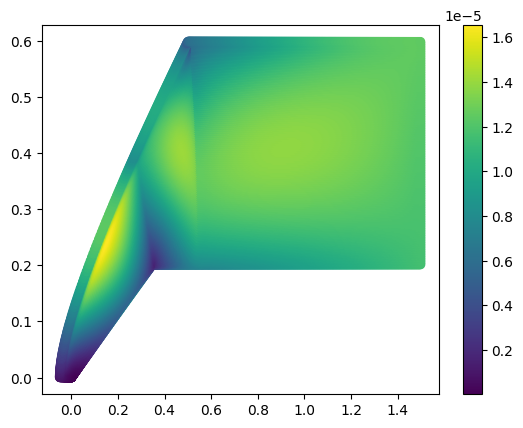

(array([[ 3.09538852e-05,  2.57089569e-04,  5.07104051e-04, ...,
          1.49072233e+00,  1.49443307e+00,  1.49814421e+00],
        [-1.34020211e-04,  7.94836694e-05,  3.38726487e-04, ...,
          1.49072001e+00,  1.49443096e+00,  1.49814323e+00],
        [-3.07137100e-04, -1.22740248e-04,  1.34852176e-04, ...,
          1.49071545e+00,  1.49442764e+00,  1.49814195e+00],
        ...,
        [-4.74712089e-02, -4.74373894e-02, -4.73874514e-02, ...,
          1.48999416e+00,  1.49400267e+00,  1.49800257e+00],
        [-4.84590757e-02, -4.84190636e-02, -4.83693374e-02, ...,
          1.48998948e+00,  1.49399931e+00,  1.49800128e+00],
        [-4.94679912e-02, -4.94240628e-02, -4.93759254e-02, ...,
          1.48998713e+00,  1.49399720e+00,  1.49800031e+00]]),
 array([[6.95126410e-05, 2.14313835e-04, 3.68069006e-04, ...,
         2.01557390e-01, 2.01559824e-01, 2.01561784e-01],
        [8.92007223e-05, 2.68359475e-04, 4.45821691e-04, ...,
         2.04675250e-01, 2.04681961e-01, 2.0468

In [ ]:
from Nozzle_2D_checkpoint4_2 import Nozzle
nozzle = Nozzle("RAMP_inputs.nml")
nozzle.load_grid("Inlet.417x129.grd")
nozzle.compute_all_areas(visualize=True)

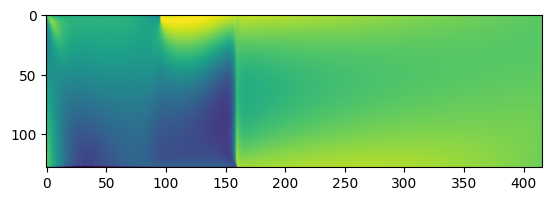

In [ ]:
plt.imshow(volume)

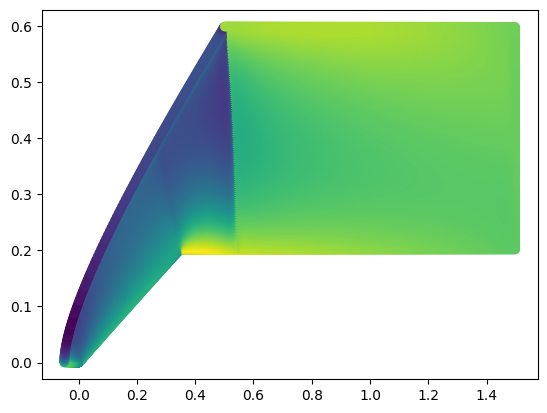

In [ ]:
plt.scatter(nozzle.midpointxx,nozzle.midpointyy,c=volume)

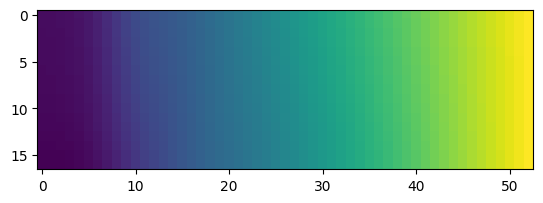

In [ ]:
plt.imshow(x)

-21.398941168849014


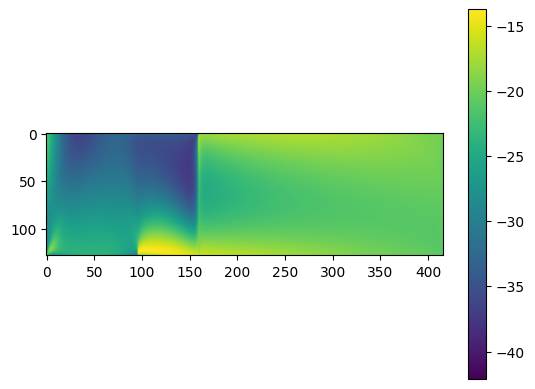

In [ ]:
print(np.median(volume))
plt.imshow(volume[::-1])
plt.colorbar()